In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\ahame\OneDrive\Desktop\Bank Customer Churn Prediction.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (10000, 12)

Columns: ['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

First 3 rows:
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  


In [3]:
import warnings
warnings.filterwarnings('ignore')

# Drop columns we don't need
df = df.drop(columns=['customer_id'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Overall churn rate
churn_rate = df['churn'].mean() * 100
print(f"\n📊 Overall Churn Rate: {churn_rate:.1f}%")

# Create age groups
df['age_group'] = pd.cut(df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['Under 30', '30-40', '40-50', '50-60', 'Over 60'])

# Create credit score groups
df['credit_group'] = pd.cut(df['credit_score'],
    bins=[0, 499, 599, 699, 799, 1000],
    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

print("\n✅ Data cleaned successfully!")
print(f"Total records: {len(df)}")
print(f"\nAge Group distribution:")
print(df['age_group'].value_counts())

Missing values:
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

📊 Overall Churn Rate: 20.4%

✅ Data cleaned successfully!
Total records: 10000

Age Group distribution:
age_group
30-40       4451
40-50       2320
Under 30    1968
50-60        797
Over 60      464
Name: count, dtype: int64


In [10]:
import sys
import subprocess

subprocess.check_call([sys.executable, '-m', 'pip', 
                      'install', 'matplotlib', 'seaborn',
                      'scikit-learn', 'pandas'])

print("✅ All libraries installed!")

✅ All libraries installed!


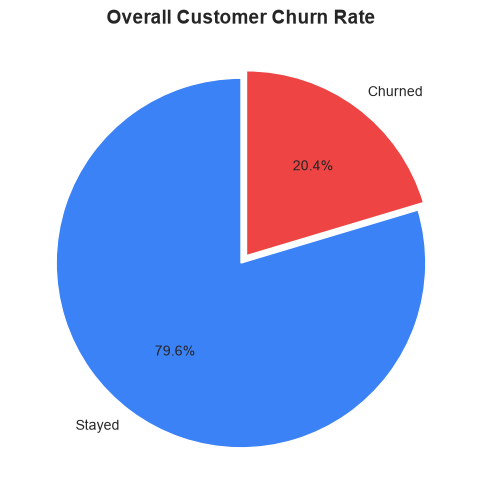

✅ Chart 1 done!


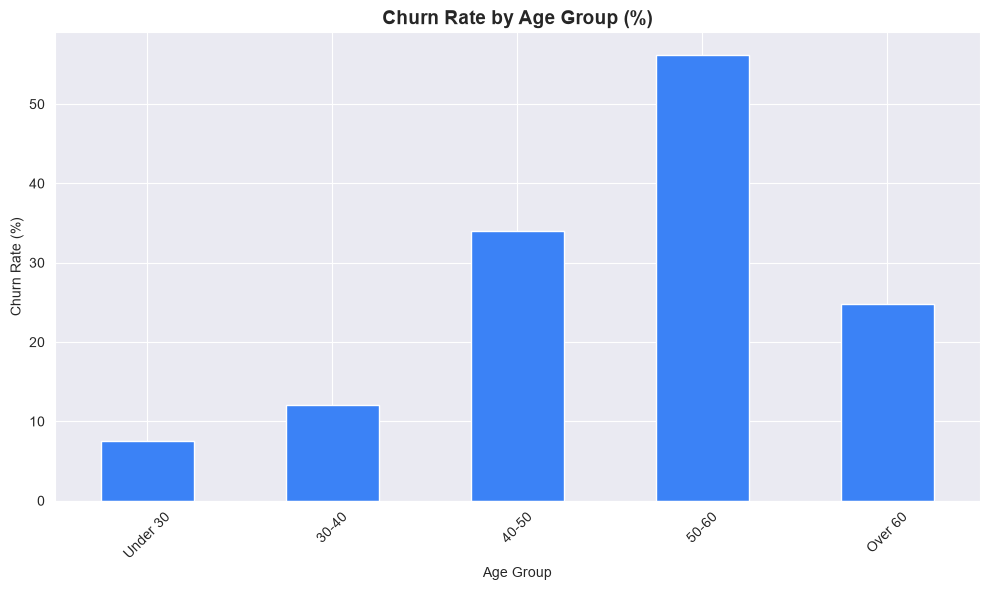

✅ Chart 2 done!


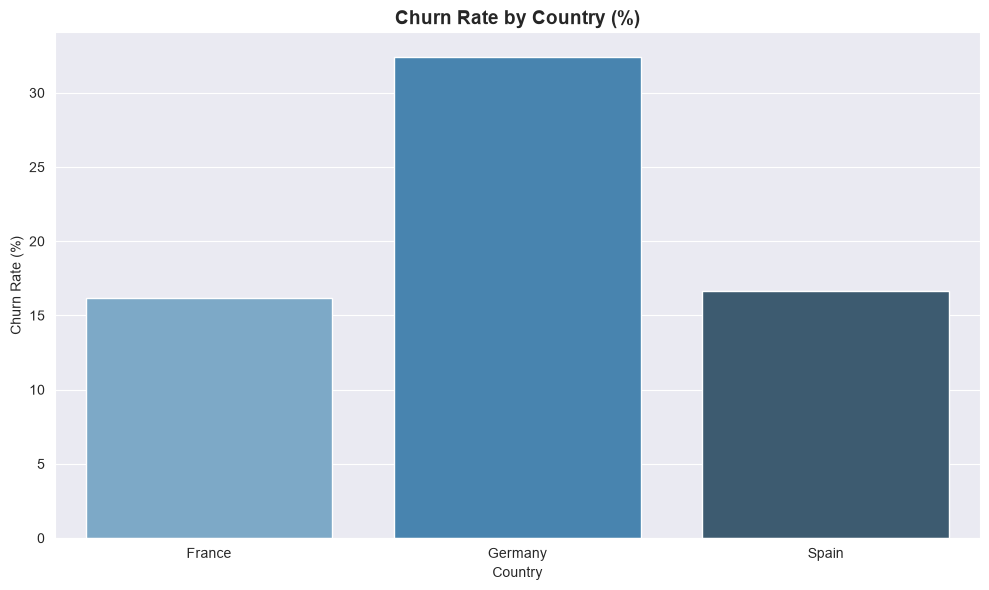

✅ Chart 3 done!


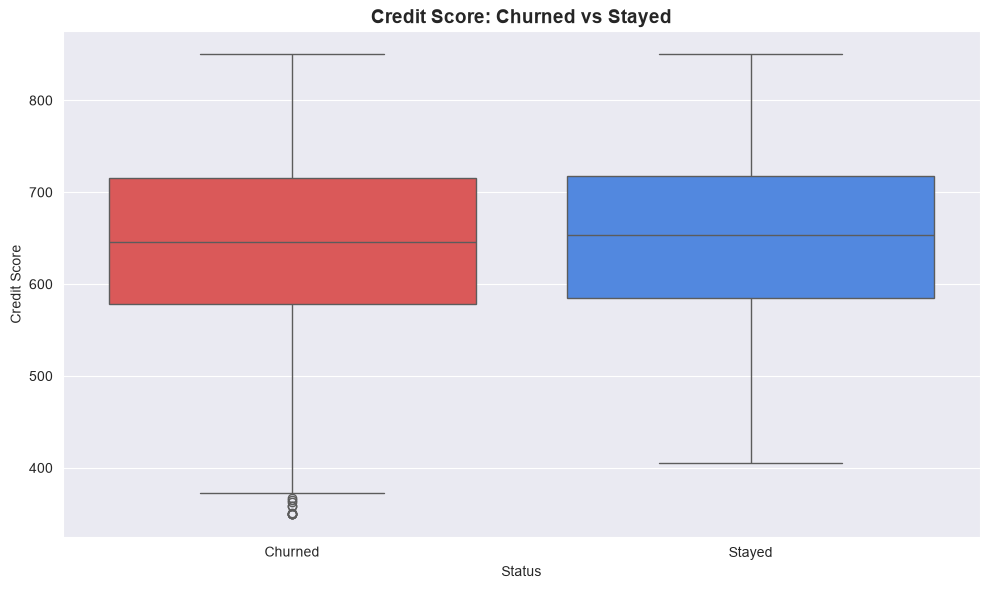

✅ Chart 4 done!


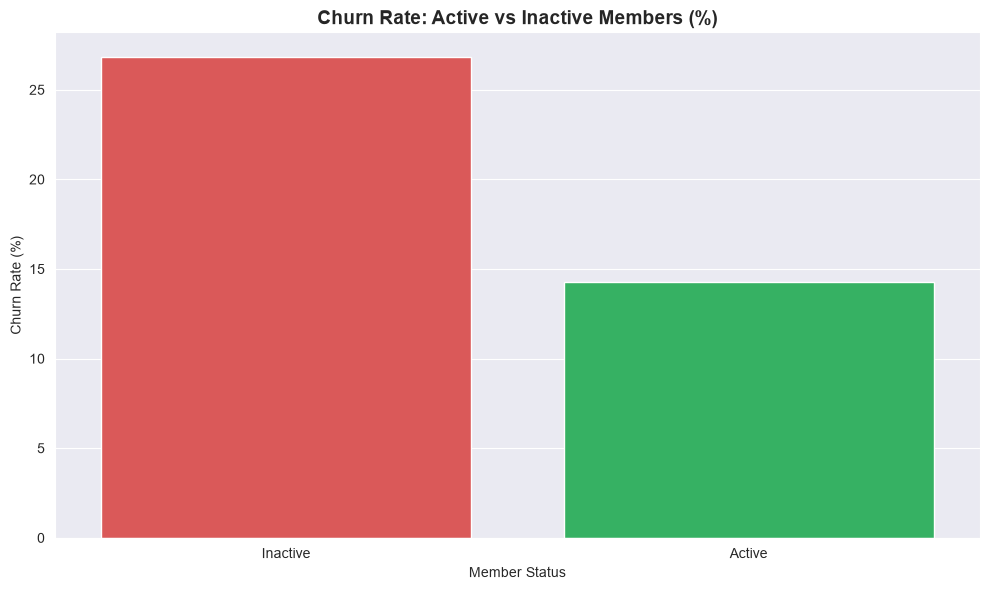

✅ Chart 5 done!

🎉 All 5 charts saved!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ---- CHART 1: Overall Churn Rate (Pie Chart) ----
churn_counts = df['churn'].value_counts()
plt.figure()
plt.pie(churn_counts, labels=['Stayed', 'Churned'],
        autopct='%1.1f%%', colors=['#3b82f6', '#ef4444'],
        startangle=90, explode=[0, 0.05])
plt.title('Overall Customer Churn Rate', fontsize=14, fontweight='bold')
plt.savefig('chart1_churn_rate.png', dpi=150)
plt.show()
print("✅ Chart 1 done!")

# ---- CHART 2: Churn by Age Group ----
plt.figure()
age_churn = df.groupby('age_group')['churn'].mean() * 100
age_churn.plot(kind='bar', color='#3b82f6', edgecolor='white')
plt.title('Churn Rate by Age Group (%)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_age_churn.png', dpi=150)
plt.show()
print("✅ Chart 2 done!")

# ---- CHART 3: Churn by Country ----
plt.figure()
country_churn = df.groupby('country')['churn'].mean() * 100
sns.barplot(x=country_churn.index, y=country_churn.values, palette='Blues_d')
plt.title('Churn Rate by Country (%)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('chart3_country_churn.png', dpi=150)
plt.show()
print("✅ Chart 3 done!")

# ---- CHART 4: Credit Score vs Churn ----
plt.figure()
df['churn_label'] = df['churn'].map({1: 'Churned', 0: 'Stayed'})
sns.boxplot(data=df, x='churn_label', y='credit_score',
            palette={'Churned': '#ef4444', 'Stayed': '#3b82f6'})
plt.title('Credit Score: Churned vs Stayed', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.savefig('chart4_creditscore.png', dpi=150)
plt.show()
print("✅ Chart 4 done!")

# ---- CHART 5: Active vs Inactive Churn ----
plt.figure()
active_churn = df.groupby('active_member')['churn'].mean() * 100
active_churn.index = ['Inactive', 'Active']
sns.barplot(x=active_churn.index, y=active_churn.values,
            palette=['#ef4444', '#22c55e'])
plt.title('Churn Rate: Active vs Inactive Members (%)', fontsize=14, fontweight='bold')
plt.xlabel('Member Status')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('chart5_active_churn.png', dpi=150)
plt.show()
print("✅ Chart 5 done!")

print("\n🎉 All 5 charts saved!")

In [12]:
import sqlite3

# Create database
conn = sqlite3.connect('churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)
print("✅ Database created!")

# Query 1 - Overall churn rate
q1 = pd.read_sql_query("""
    SELECT 
        COUNT(*) AS total_customers,
        SUM(churn) AS churned,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM customers
""", conn)
print("\n📊 Query 1 - Overall Churn Rate:")
print(q1)

# Query 2 - Churn by country
q2 = pd.read_sql_query("""
    SELECT 
        country,
        COUNT(*) AS total,
        SUM(churn) AS churned,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY country
    ORDER BY churn_rate_pct DESC
""", conn)
print("\n📊 Query 2 - Churn by Country:")
print(q2)

# Query 3 - Churn by age group
q3 = pd.read_sql_query("""
    SELECT 
        age_group,
        COUNT(*) AS total,
        SUM(churn) AS churned,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY age_group
    ORDER BY churn_rate_pct DESC
""", conn)
print("\n📊 Query 3 - Churn by Age Group:")
print(q3)

# Query 4 - Active vs Inactive
q4 = pd.read_sql_query("""
    SELECT 
        CASE active_member 
            WHEN 1 THEN 'Active'
            WHEN 0 THEN 'Inactive'
        END AS member_status,
        COUNT(*) AS total,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct,
        ROUND(AVG(balance), 2) AS avg_balance
    FROM customers
    GROUP BY active_member
""", conn)
print("\n📊 Query 4 - Active vs Inactive:")
print(q4)

# Query 5 - High risk segments
q5 = pd.read_sql_query("""
    SELECT 
        country,
        gender,
        credit_group,
        COUNT(*) AS total,
        ROUND(SUM(churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct
    FROM customers
    GROUP BY country, gender, credit_group
    HAVING total > 30
    ORDER BY churn_rate_pct DESC
    LIMIT 10
""", conn)
print("\n📊 Query 5 - Top High Risk Segments:")
print(q5)

print("\n✅ All 5 SQL queries done!")

✅ Database created!

📊 Query 1 - Overall Churn Rate:
   total_customers  churned  churn_rate_pct
0            10000     2037           20.37

📊 Query 2 - Churn by Country:
   country  total  churned  churn_rate_pct
0  Germany   2509      814           32.44
1    Spain   2477      413           16.67
2   France   5014      810           16.15

📊 Query 3 - Churn by Age Group:
  age_group  total  churned  churn_rate_pct
0     50-60    797      448           56.21
1     40-50   2320      788           33.97
2   Over 60    464      115           24.78
3     30-40   4451      538           12.09
4  Under 30   1968      148            7.52

📊 Query 4 - Active vs Inactive:
  member_status  total  churn_rate_pct  avg_balance
0      Inactive   4849           26.85     77134.38
1        Active   5151           14.27     75875.42

📊 Query 5 - Top High Risk Segments:
   country  gender credit_group  total  churn_rate_pct
0  Germany  Female         Poor     81           40.74
1  Germany  Female    V

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

print("✅ All ML libraries imported!")

# ---- Prepare data for ML ----
df_ml = df.copy()

# Convert text columns to numbers
le = LabelEncoder()
df_ml['country']  = le.fit_transform(df_ml['country'])
df_ml['gender']   = le.fit_transform(df_ml['gender'])

# Drop non-numeric columns
df_ml = df_ml.drop(columns=['age_group', 'credit_group', 
                              'churn_label'], errors='ignore')

# Features and target
X = df_ml.drop(columns=['churn'])
y = df_ml['churn']

print(f"Features: {list(X.columns)}")
print(f"Total samples: {len(X)}")
print(f"Churn count: {y.sum()} ({y.mean()*100:.1f}%)")

✅ All ML libraries imported!
Features: ['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']
Total samples: 10000
Churn count: 2037 (20.4%)


Training samples: 8000
Testing samples:  2000

✅ Model trained!

🎯 Accuracy:  82.0%

📋 Full Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.85      0.88      1593
     Churned       0.55      0.70      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



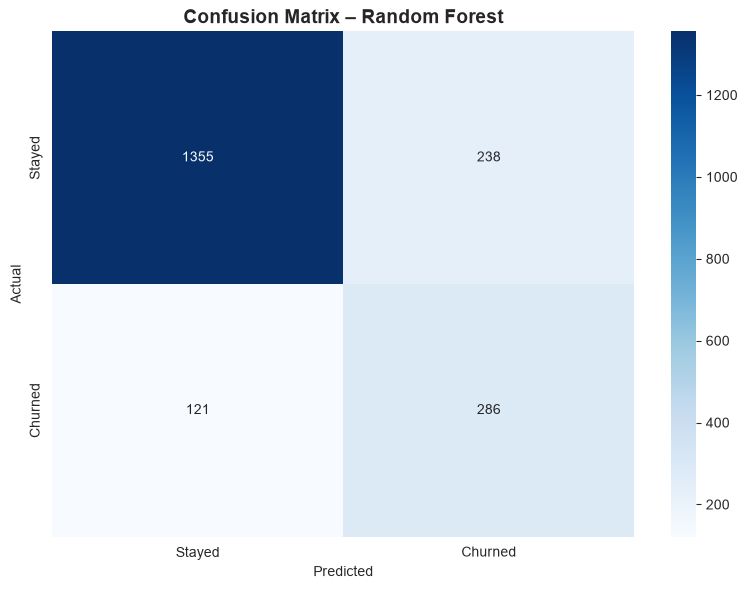

✅ Chart 6 saved!


In [14]:
# ---- Split data into train and test ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# ---- Train Random Forest ----
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print("\n✅ Model trained!")

# ---- Evaluate Model ----
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\n🎯 Accuracy:  {accuracy:.1f}%")
print(f"\n📋 Full Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Stayed', 'Churned']))

# ---- Confusion Matrix Chart ----
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix – Random Forest', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('chart6_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Chart 6 saved!")

📊 Top Churn Drivers:
         Feature  Importance_Pct
             age            32.8
 products_number            21.6
         balance            11.3
estimated_salary             8.4
    credit_score             8.0
   active_member             5.6
          tenure             4.6
         country             4.5
          gender             2.2
     credit_card             1.1


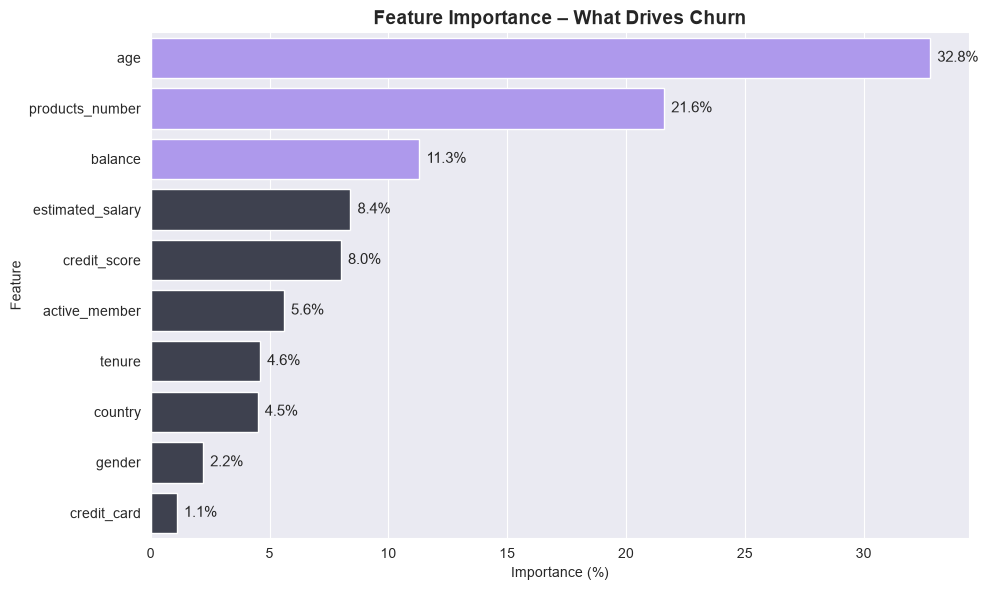

✅ Chart 7 saved!

💡 Business Recommendations:

#1 AGE (32.8% importance)
   → Launch retention programs targeting customers aged 50-60

#2 PRODUCTS_NUMBER (21.6% importance)
   → Encourage multi-product usage via bundled offers

#3 BALANCE (11.3% importance)
   → Offer premium services to high-balance customers



In [15]:
# ---- Feature Importance ----
importances = rf_model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

feat_df['Importance_Pct'] = (feat_df['Importance'] * 100).round(1)

print("📊 Top Churn Drivers:")
print(feat_df[['Feature', 'Importance_Pct']].to_string(index=False))

# ---- Feature Importance Chart ----
plt.figure(figsize=(10, 6))
colors = ['#a78bfa' if i < 3 else '#3b3f52' 
          for i in range(len(feat_df))]

sns.barplot(data=feat_df, x='Importance_Pct', 
            y='Feature', palette=colors)

plt.title('Feature Importance – What Drives Churn',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance (%)')
plt.ylabel('Feature')

for i, val in enumerate(feat_df['Importance_Pct']):
    plt.text(val + 0.3, i, f'{val}%', va='center', fontsize=11)

plt.tight_layout()
plt.savefig('chart7_feature_importance.png', dpi=150)
plt.show()
print("✅ Chart 7 saved!")

# ---- Business Recommendations ----
print("\n💡 Business Recommendations:\n")
top3 = feat_df.head(3)
recommendations = {
    'age':            'Launch retention programs targeting customers aged 50-60',
    'balance':        'Offer premium services to high-balance customers',
    'active_member':  'Re-engage inactive members with personalized campaigns',
    'products_number':'Encourage multi-product usage via bundled offers',
    'credit_score':   'Provide credit improvement programs for at-risk segments',
    'country':        'Focus retention efforts on Germany — 32% churn rate',
    'estimated_salary':'Target salary-based premium loyalty programs',
    'tenure':         'Reward long-term customers with exclusive benefits',
    'gender':         'Design gender-specific retention campaigns',
    'credit_card':    'Promote credit card benefits to non-holders'
}

for i, row in top3.iterrows():
    feat = row['Feature']
    pct  = row['Importance_Pct']
    rec  = recommendations.get(feat, 'Investigate this factor further')
    rank = list(feat_df['Feature']).index(feat) + 1
    print(f"#{rank} {feat.upper()} ({pct}% importance)")
    print(f"   → {rec}\n")

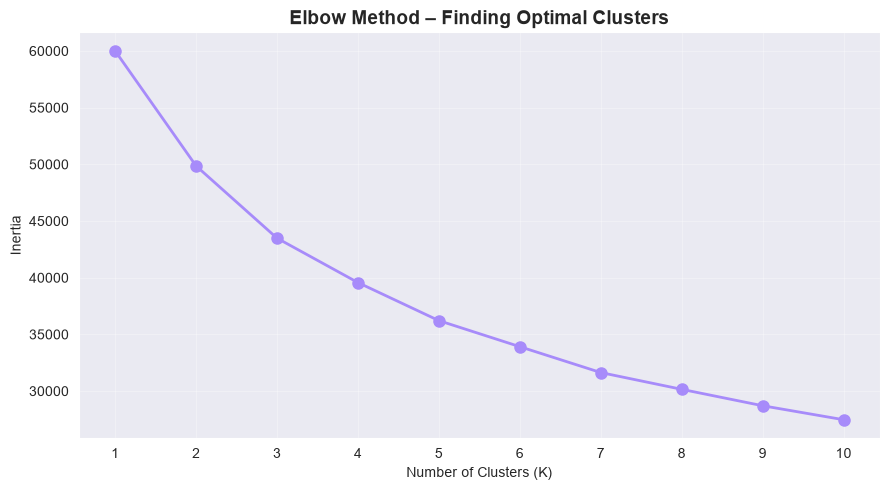

✅ Chart 8 saved!

Look at the chart — where does the curve bend/flatten?
That number is your best K value (usually 3 or 4)


In [16]:
# ---- K-Means Customer Segmentation ----

# Select features for clustering
cluster_features = ['age', 'balance', 'credit_score',
                    'products_number', 'active_member', 'tenure']

X_cluster = df[cluster_features].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Find best number of clusters (Elbow Method)
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Elbow Chart
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker='o', 
         color='#a78bfa', linewidth=2, markersize=8)
plt.title('Elbow Method – Finding Optimal Clusters',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart8_elbow.png', dpi=150)
plt.show()
print("✅ Chart 8 saved!")
print("\nLook at the chart — where does the curve bend/flatten?")
print("That number is your best K value (usually 3 or 4)")

📊 Cluster Summary:
         Avg Age  Avg Balance  Avg Credit  Avg Products  Active Rate  \
cluster                                                                
0          35.89      9501.64      650.45          2.13         0.49   
1          35.33    107773.44      653.89          1.29         1.00   
2          37.53    105934.80      647.50          1.27         0.00   
3          59.92     75298.42      650.89          1.44         0.84   

         Churn Rate  
cluster              
0              0.12  
1              0.13  
2              0.29  
3              0.36  

✅ Segments created:
segment
🟡 At Risk      3258
🔵 Stable       2878
🟢 Loyal        2757
🔴 High Risk    1107
Name: count, dtype: int64


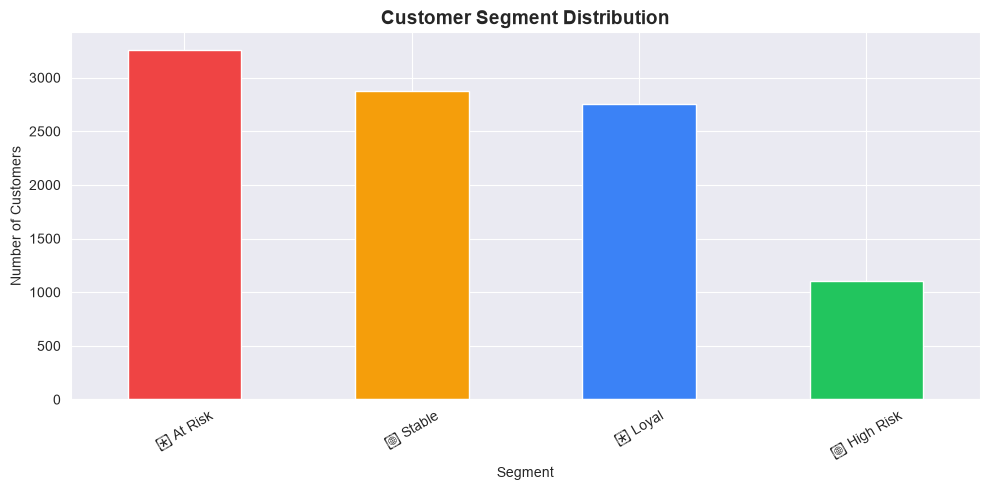

✅ Chart 9 saved!


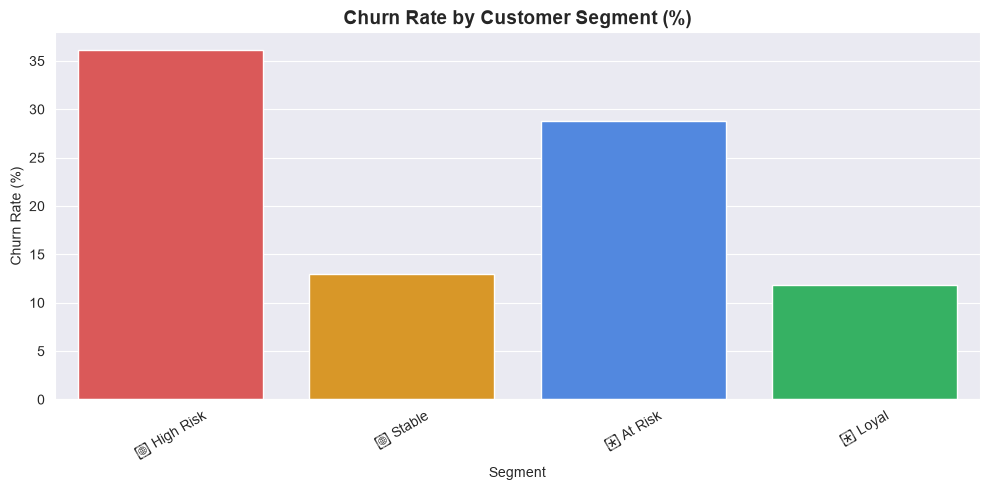

✅ Chart 10 saved!

🎉 ALL DONE! Final dataset saved as churn_final_powerbi.csv
Import this file into Power BI to build your dashboard!


In [17]:
# ---- Run K-Means with 4 clusters ----
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze each cluster
cluster_summary = df.groupby('cluster').agg({
    'age':            'mean',
    'balance':        'mean',
    'credit_score':   'mean',
    'products_number':'mean',
    'active_member':  'mean',
    'churn':          'mean'
}).round(2)

cluster_summary.columns = ['Avg Age', 'Avg Balance', 'Avg Credit',
                            'Avg Products', 'Active Rate', 'Churn Rate']
print("📊 Cluster Summary:")
print(cluster_summary)

# Label segments based on churn rate
churn_rates = cluster_summary['Churn Rate']
labels = {}
labels[churn_rates.idxmax()] = '🔴 High Risk'
labels[churn_rates.idxmin()] = '🟢 Loyal'

for c in cluster_summary.index:
    if c not in labels:
        cr = cluster_summary.loc[c, 'Churn Rate']
        labels[c] = '🟡 At Risk' if cr > 0.2 else '🔵 Stable'

df['segment'] = df['cluster'].map(labels)
print("\n✅ Segments created:")
print(df['segment'].value_counts())

# ---- Chart 9: Segment Distribution ----
plt.figure(figsize=(10, 5))
segment_counts = df['segment'].value_counts()
colors = ['#ef4444', '#f59e0b', '#3b82f6', '#22c55e']
segment_counts.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Customer Segment Distribution', 
          fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart9_segments.png', dpi=150)
plt.show()
print("✅ Chart 9 saved!")

# ---- Chart 10: Churn Rate per Segment ----
plt.figure(figsize=(10, 5))
churn_by_seg = df.groupby('segment')['churn'].mean() * 100
sns.barplot(x=churn_by_seg.index, y=churn_by_seg.values, 
            palette=colors)
plt.title('Churn Rate by Customer Segment (%)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart10_churn_by_segment.png', dpi=150)
plt.show()
print("✅ Chart 10 saved!")

# ---- Save Final Dataset for Power BI ----
df.to_csv('churn_final_powerbi.csv', index=False)
print("\n🎉 ALL DONE! Final dataset saved as churn_final_powerbi.csv")
print("Import this file into Power BI to build your dashboard!")